In [8]:
from pts_iterator import pts_iterator
from spiral import SpiralPath
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    format='%(asctime)s - %(levelname)s - %(message)s'
)
from fit_gaussian import  fit_and_plot,fit_gaussian_2d,gaussian_2d
import matplotlib.pyplot as plt

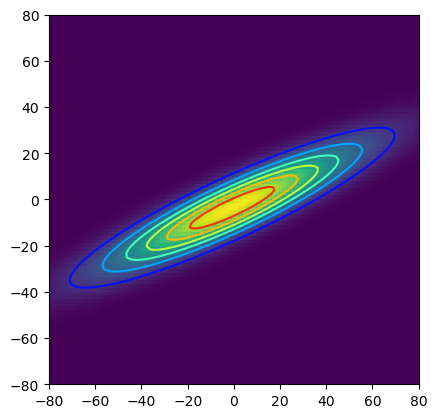

In [12]:
a = np.load("/home/rydpiservo/servodata/x_xdot_sample.npz")
X,Y,Z = a['X'],a['Y'],a['Z']
popt = fit_and_plot(X,Y,Z)

In [16]:
f = lambda xy: gaussian_2d(xy,*popt)
f((0,0))

array([12478.78401466])

In [20]:
def callback_func(paras):
    x,y = paras
    z = f(paras)
    return x,y,z

  0%|          | 0/150 [00:00<?, ?it/s]2024-09-17 16:03:42,497 - INFO - Reset origin at -22.984926636795425, -31.600320108412916, I_max= 628.8863597742029
2024-09-17 16:03:42,503 - INFO - Reset origin at -15.208432213503462, -24.771344763210983, I_max= 1806.0256027985492
2024-09-17 16:03:42,507 - INFO - Reset origin at -29.161850047732745, -22.060628316624214, I_max= 7378.988326343925
2024-09-17 16:03:42,519 - INFO - Reset origin at -7.645182937471603, -7.158382510825019, I_max= 13444.59735131377
 93%|█████████▎| 140/150 [00:00<00:00, 2389.28it/s]
2024-09-17 16:03:42,543 - INFO - Converged position: (4.451524561610842, -0.7588990826456389)
2024-09-17 16:03:42,588 - INFO - Best position: x=2.156522138184103, y=-1.6358562391214422, I=13637.858623821892


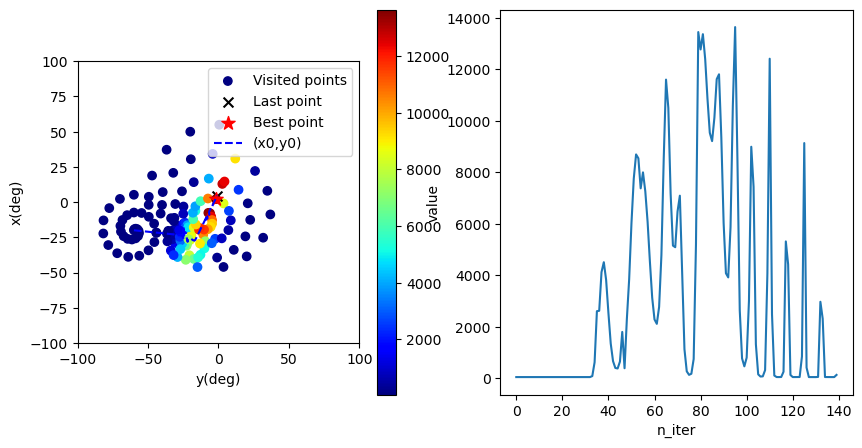

In [30]:
sp= SpiralPath()
spiral_params = {
    'I_meaningful': 80,
    'D': 2,
    'SPIRAL_RESOLUTION': 20,
    'SPIRAL_SPAN': 10,
    'SINGLE_SPIRAL_SPAN': 3,
    'N_LOOPS_BEFORE_RESET_ORIGIN': 0.2,
    'MAX_X0Y0_DISPLACEMENT': 10,
    'COEF_I_RESET_ORIGIN': 1.2,
    'alpha': 0.02,
    'COEF_I_DECAY': 0.99
}

#
bounds = [(-100,100),(-100,100)]

try:
    # POS_MASK = X_Y_MASK
    # POS_MASK = XDOT_YDOT_MASK
    # POS_MASK = X_XDOT_MASK
    x0,y0 = pts_iterator(callback_func=callback_func ,p0=[0,0], bounds = bounds, method = "spiral")
except Exception as e:
    print(e)